# Deney 3 - Vishing Senaryolarinda Alpha-Beta Budamasi ve Heuristik Sabotaj AnaliziBu notebook, `fixed_solution.py` icindeki duzeltilmis modeli calistirir, `raw_llm_solution.py` ile karsilastirir ve rapor ile sunulan tum metrik ve grafikleri uretir.

In [1]:
import copyimport pandas as pdimport matplotlib.pyplot as pltimport raw_llm_solution as hamimport fixed_solution as duzeltilmis

## 1. Baslangic Durumu ve Eylem Tablolari

In [2]:
duzeltilmis.baslangic_durumu()

{'turn': 0, 'risk_score': 0, 'trust_level': 50, 'pressure_level': 0, 'disclosed_info': 0, 'verification_status': 0, 'conversation_status': 'devam', 'sonlandirma_riski': None}

In [3]:
pd.DataFrame(duzeltilmis.ATTACKER_ACTIONS).T

,risk,trust,pressure
A1,10,0,20
A2,12,10,10
A3,5,20,0
A4,15,-5,25
A5,10,15,5
A6,25,-10,10
A7,30,-15,15
A8,15,15,10


In [4]:
pd.DataFrame(duzeltilmis.DEFENDER_ACTIONS).T

,risk,trust,cost
D1,0,0,0
D2,-10,-5,2
D3,-20,-10,5
D4,-30,-15,8
D5,-40,-25,12


## 2. Minimax ve Alpha-Beta Dugum Sayisi Karsilastirmasi

In [5]:
duzeltilmis.dugum_sayaci = 0duzeltilmis.minimax(duzeltilmis.baslangic_durumu(), 6, True)mm_dugum = duzeltilmis.dugum_sayaciduzeltilmis.dugum_sayaci = 0duzeltilmis.alpha_beta(duzeltilmis.baslangic_durumu(), 6, float('-inf'), float('inf'), True)ab_dugum = duzeltilmis.dugum_sayacimm_dugum, ab_dugum, round((1 - ab_dugum / mm_dugum) * 100, 2)

(5734, 1338, 76.67)

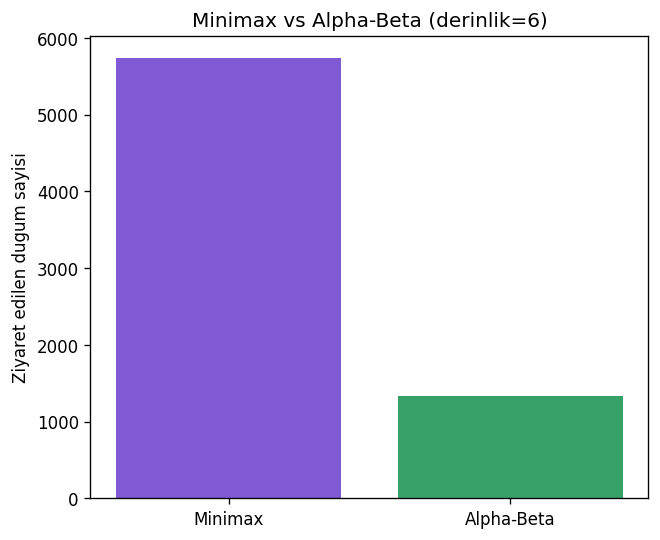

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))ax.bar(['Minimax', 'Alpha-Beta'], [mm_dugum, ab_dugum], color=['#805ad5', '#38a169'])ax.set_ylabel('Ziyaret edilen dugum sayisi')ax.set_title('Minimax vs Alpha-Beta (derinlik=6)')plt.show()

## 3. BUG-1: Heuristik Fonksiyonundaki disclosed_info Agirlik Hatasi

In [7]:
satirlar = []for eylem in ham.ATTACKER_ACTIONS:    durum_hatali = ham.saldirgan_uygula(ham.baslangic_durumu(), eylem)    durum_dogru = duzeltilmis.saldirgan_uygula(duzeltilmis.baslangic_durumu(), eylem)    hv = ham.heuristik(durum_hatali)    dv = duzeltilmis.heuristik(durum_dogru)    satirlar.append({'eylem': eylem, 'dogru_heuristik': dv, 'hatali_heuristik': hv, 'fark': hv - dv})df_heuristik = pd.DataFrame(satirlar)df_heuristik

,eylem,dogru_heuristik,hatali_heuristik,fark
0,A1,-11.0,-11.0,0.0
1,A2,-9.0,-9.0,0.0
2,A3,2.0,2.0,0.0
3,A4,-18.0,-18.0,0.0
4,A5,-5.0,-5.0,0.0
5,A6,-49.0,-29.0,20.0
6,A7,-56.0,-36.0,20.0
7,A8,-11.5,-11.5,0.0


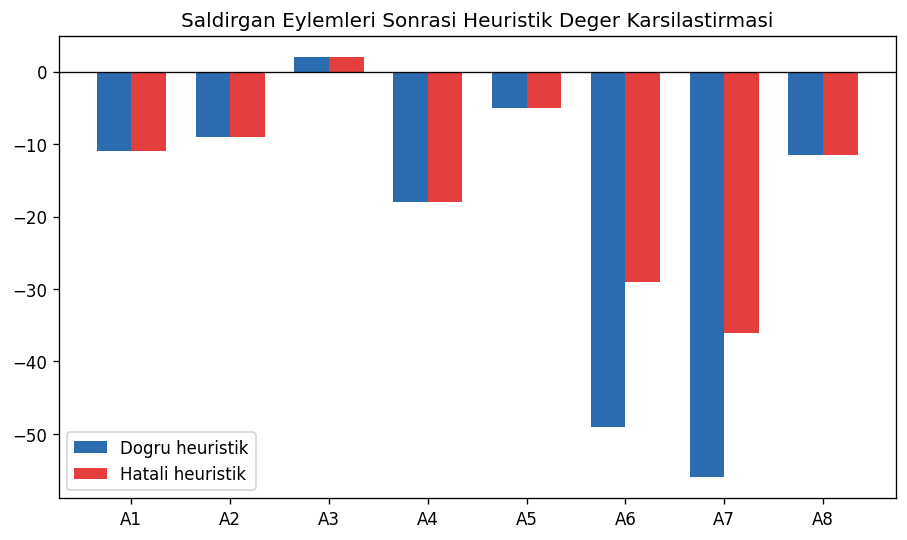

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))x = range(len(df_heuristik))w = 0.35ax.bar([i - w/2 for i in x], df_heuristik['dogru_heuristik'], width=w, label='Dogru heuristik', color='#2b6cb0')ax.bar([i + w/2 for i in x], df_heuristik['hatali_heuristik'], width=w, label='Hatali heuristik', color='#e53e3e')ax.set_xticks(list(x))ax.set_xticklabels(df_heuristik['eylem'])ax.axhline(0, color='black', linewidth=0.8)ax.legend()ax.set_title('Saldirgan Eylemleri Sonrasi Heuristik Deger Karsilastirmasi')plt.show()

## 4. BUG-2: D5 Terminal Esik Hatasi

In [9]:
def kritik_durum_uret(modul):    d = modul.baslangic_durumu()    d = modul.saldirgan_uygula(d, 'A6')    d = modul.savunucu_uygula(d, 'D1')    d = modul.saldirgan_uygula(d, 'A7')    return dd_hatali = ham.savunucu_uygula(kritik_durum_uret(ham), 'D5')d_dogru = duzeltilmis.savunucu_uygula(kritik_durum_uret(duzeltilmis), 'D5')_, sonuc_hatali = ham.terminal_kontrol(d_hatali)_, sonuc_dogru = duzeltilmis.terminal_kontrol(d_dogru)sonuc_hatali, sonuc_dogru

(-30, 90)

## 5. BUG-3: trust_level Sinir (Clamp) Hatasi

In [10]:
d_h = ham.baslangic_durumu()d_d = duzeltilmis.baslangic_durumu()for _ in range(3):    d_h = ham.saldirgan_uygula(d_h, 'A3')    d_d = duzeltilmis.saldirgan_uygula(d_d, 'A3')d_h['trust_level'], d_d['trust_level']

(110, 100)

## 6. Esik Tabanli Ajan ile Somuru SenaryosuKural: `heuristik(durum) < -45` ise D3 (dogrula), aksi halde D1 (izlemeye devam et).

In [11]:
ESIK = -45def esik_ajan(modul, durum):    v = modul.heuristik(durum)    return ('D3', v) if v < ESIK else ('D1', v)sonuclar = {}for etiket, modul in (('dogru', duzeltilmis), ('hatali', ham)):    d = modul.baslangic_durumu()    d = modul.saldirgan_uygula(d, 'A6')    eylem, deger = esik_ajan(modul, d)    adimlar = [('A6', d['disclosed_info'], deger, eylem)]    if eylem == 'D1':        d = modul.savunucu_uygula(d, eylem)        d = modul.saldirgan_uygula(d, 'A7')        eylem2, deger2 = esik_ajan(modul, d)        adimlar.append(('A7', d['disclosed_info'], deger2, eylem2))    sonuclar[etiket] = adimlarsonuclar

{'dogru': [('A6', 1, -49.0, 'D3')], 'hatali': [('A6', 1, -29.0, 'D1'), ('A7', 2, -70.0, 'D3')]}

## 7. Tum Metriklerin CSV Olarak Kaydedilmesi

In [12]:
df_sonuclar = pd.read_csv('results.csv')df_sonuclar

,kategori,senaryo_veya_eylem,duzeltilmis_dogru_deger,ham_hatali_deger,fark,aciklama
0,heuristik_karsilastirma,A1 Aciliyet vurgusu,-11.0,-11.0,0.0,disclosed_info degismedigi icin fark yok
1,heuristik_karsilastirma,A2 Otorite iddiasi,-9.0,-9.0,0.0,disclosed_info degismedigi icin fark yok
2,heuristik_karsilastirma,A3 Guven kazanma,2.0,2.0,0.0,disclosed_info degismedigi icin fark yok
3,heuristik_karsilastirma,A4 Korku olusturma,-18.0,-18.0,0.0,disclosed_info degismedigi icin fark yok
4,heuristik_karsilastirma,A5 Odul/avantaj vaadi,-5.0,-5.0,0.0,disclosed_info degismedigi icin fark yok
5,heuristik_karsilastirma,A6 Kimlik bilgisi isteme,-49.0,-29.0,20.0,BUG1 - hatali heuristik riski 20 puan dusuk go...
6,heuristik_karsilastirma,A7 Finansal islem yonlendirmesi,-56.0,-36.0,20.0,BUG1 - hatali heuristik riski 20 puan dusuk go...
7,heuristik_karsilastirma,A8 Teknik destek bahanesi,-11.5,-11.5,0.0,disclosed_info degismedigi icin fark yok
8,bug2_d5_esik_hatasi,A6->D1->A7->D5 senaryosu,90,-30,120,BUG2 - ham kod D5 icin risk_score'u indirim so...
9,bug3_trust_clamp,3x A3 sonrasi trust_level,100,110,-10,BUG3 - ham kodda trust_level 100 sinirini asiyor


## 8. SonucDuzeltilmis cozum (`fixed_solution.py`), ham LLM cozumunde (`raw_llm_solution.py`) tespit edilen uc hatayi (heuristik agirlik hatasi, D5 esik hatasi, trust_level clamp hatasi) gidermektedir. Detaylar `llm_error_log.xlsx` dosyasinda, gorseller `figures/` klasorunde, tum sayisal metrikler ise `results.csv` dosyasinda yer almaktadir.